# Multi-sample Pipeline: analyzing snATAC-seq data of human spine samples

## Load

In [1]:
import snapatac2 as snap
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2'

snap.__version__

'2.6.4'

In [2]:
# Define sample IDs
samples = ["GW7", "GW12", "GW6", "GW9", "GW10", "GW16", "GW17", "GW20"]

# Paths to Cell Ranger RNA count matrices (filtered_feature_bc_matrix)
fragment_files = tuple(
    (sample, os.path.join("/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger", sample, "outs/atac_fragments.tsv.gz"))
    for sample in samples[:2]
) + tuple(
    (sample, os.path.join("/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger", sample, "outs/atac_fragments.tsv.gz"))
    for sample in samples[2:]
)

fragment_files

(('GW7',
  '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW7/outs/atac_fragments.tsv.gz'),
 ('GW12',
  '/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger/GW12/outs/atac_fragments.tsv.gz'),
 ('GW6',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW6/outs/atac_fragments.tsv.gz'),
 ('GW9',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW9/outs/atac_fragments.tsv.gz'),
 ('GW10',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW10/outs/atac_fragments.tsv.gz'),
 ('GW16',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW16/outs/atac_fragments.tsv.gz'),
 ('GW17',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW17/outs/atac_fragments.tsv.gz'),
 ('GW20',
  '/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger/GW20/outs/atac_fragments.tsv.gz

In [3]:
%%time
adatas = snap.pp.import_data(
    [file for _, file in fragment_files],
    file=[sample + '_raw.h5ad' for sample, _ in fragment_files],
    chrom_sizes=snap.genome.hg38,
    min_num_fragments=1000,
    sorted_by_barcode=False
)

100%|██████████| 8/8 [06:34<00:00, 49.37s/it] 


CPU times: user 197 ms, sys: 732 ms, total: 929 ms
Wall time: 6min 36s


In [4]:
adatas

[AnnData object with n_obs x n_vars = 12415 x 0 backed at 'GW7_raw.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 11173 x 0 backed at 'GW12_raw.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 16851 x 0 backed at 'GW6_raw.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 10486 x 0 backed at 'GW9_raw.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 11093 x 0 backed at 'GW10_raw.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 19452 x 0 backed at 'GW16_raw.h5ad'
     obs:

In [5]:
%%time
snap.metrics.tsse(adatas, snap.genome.hg38)
snap.pp.add_tile_matrix(adatas, bin_size=5000)
snap.pp.select_features(adatas, n_features=250000)

100%|██████████| 8/8 [00:15<00:00,  1.88s/it]

CPU times: user 478 ms, sys: 489 ms, total: 967 ms
Wall time: 1min 50s


## Creating AnnDataSet object

In [6]:
%%time
data = snap.AnnDataSet(
    adatas=[(sample, adata) for (sample, _), adata in zip(fragment_files, adatas)],
    filename="hsc_raw.h5ads"
)
data

CPU times: user 672 ms, sys: 1.28 s, total: 1.96 s
Wall time: 1.7 s


AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at 'hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'

In [7]:
data.close()

In [8]:
data = snap.read_dataset("hsc_raw.h5ads")
data

AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at 'hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'

In [9]:
data.adatas

Stacked AnnData objects:
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    obsm: 'fragment_paired'

In [10]:
data.obsm['fragment_paired'] = data.adatas.obsm['fragment_paired']

In [11]:
print(f'Number of cells: {data.n_obs}')
print(f'Number of unique barcodes: {np.unique(data.obs_names).size}')

Number of cells: 109782
Number of unique barcodes: 102554


In [12]:
suffixes = [f"-{i}" for i in range(len(samples))]

sample_suffix_map = dict(zip(samples, suffixes))

In [13]:
unique_cell_ids = [bc + sample_suffix_map[sample] for sample, bc in zip(data.obs['sample'], data.obs_names)]

In [14]:
data.obs_names = unique_cell_ids
assert data.n_obs == np.unique(data.obs_names).size

In [15]:
data.obs_names

['AAACAGCCAACACTTG-1-0',
 'AAACAGCCAGCAAGAT-1-0',
 'AAACAGCCAGCAAGTG-1-0',
 'AAACAGCCAGGCATCT-1-0',
 'AAACAGCCATAAAGCA-1-0',
 'AAACAGCCATATTGAC-1-0',
 'AAACAGCCATCGTTCT-1-0',
 'AAACAGCCATTAGGTT-1-0',
 'AAACAGCCATTCCTGT-1-0',
 'AAACAGCCATTGCGAC-1-0',
 'AAACATGCAATAACGA-1-0',
 'AAACATGCAATTAGCT-1-0',
 'AAACATGCACAGGATG-1-0',
 'AAACATGCAGACAAAC-1-0',
 'AAACCAACAAAGCTCC-1-0',
 'AAACCAACAACTAGAA-1-0',
 'AAACCAACAATGCCTA-1-0',
 'AAACCAACACAATGCC-1-0',
 'AAACCAACACCAGCAT-1-0',
 'AAACCAACACCTATAG-1-0',
 'AAACCAACAGTTATGT-1-0',
 'AAACCAACATGGTTAT-1-0',
 'AAACCAACATGTCGCG-1-0',
 'AAACCGAAGACCATAC-1-0',
 'AAACCGAAGAGGGACT-1-0',
 'AAACCGAAGGACACTT-1-0',
 'AAACCGAAGGTCCACA-1-0',
 'AAACCGAAGTCATGCG-1-0',
 'AAACCGAAGTTAGGCT-1-0',
 'AAACCGAAGTTGGGCC-1-0',
 'AAACCGCGTCAATACG-1-0',
 'AAACCGCGTGGAGCAA-1-0',
 'AAACCGCGTTGAGGTC-1-0',
 'AAACCGCGTTTCCTCC-1-0',
 'AAACCGGCAAATTCGT-1-0',
 'AAACCGGCAAATTGCT-1-0',
 'AAACCGGCACATTGCA-1-0',
 'AAACCGGCACCTGCCT-1-0',
 'AAACCGGCACTAAGAA-1-0',
 'AAACCGGCACTGGCTG-1-0',


## Select cells we need

In [16]:
select_cells = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/Scanpy/metadata_hscAdata_annotated_dual_final.csv', index_col=0)
select_cells

,Sample,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,cell_type,cell_type_dual,cell_type_cluster,cluster_res_2.8,cell_type_order
AAACAGCCAAATACCT-1-7,GW20,7,935,6.841615,1632.0,7.398174,27.144608,38.235294,51.470588,73.345588,...,1.593137,0.0,0.000000,0.000000,0,Ex-IN,Ex-IN,Ex-IN-1,0,Ex-IN
AAACAGCCAAATATCC-1-7,GW20,7,4157,8.332789,10069.0,9.217316,16.486245,23.021154,31.313934,46.082034,...,1.569173,4.0,1.609438,0.039726,1,Astrocytes,Astrocytes,Astrocytes-1,1,Astrocytes
AAACAGCCAAATGCCC-1-4,GW10,4,1298,7.169350,2096.0,7.648263,23.234733,31.583969,42.748092,61.927481,...,1.526717,2.0,1.098612,0.095420,6,In-IN,In-IN,In-IN-1,6,In-IN
AAACAGCCAACACTTG-1-0,GW7,0,3240,8.083637,7230.0,8.886132,20.304288,26.998617,35.394191,50.484094,...,1.908714,1.0,0.693147,0.013831,11,DRG,DRG,DRG-2,11,DRG
AAACAGCCAACAGGAT-1-7,GW20,7,1379,7.229839,2199.0,7.696213,19.190541,28.012733,39.017735,60.027285,...,1.318781,0.0,0.000000,0.000000,12,OPC,OPC,OPC-1,12,OPC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTGTCATC-1-3,GW9,3,2972,7.997327,6747.0,8.817001,17.370683,24.129243,33.540833,50.881873,...,1.793390,1.0,0.693147,0.014821,6,In-IN,In-IN,In-IN-1,6,In-IN
TTTGTTGGTTGTCCAT-1-1,GW12,1,2339,7.757906,5054.0,8.528133,18.519984,26.612584,37.020182,55.777602,...,0.633162,0.0,0.000000,0.000000,51,APC,APC,APC,51,APC
TTTGTTGGTTGTTGGA-1-6,GW17,6,3616,8.193400,9766.0,9.186765,19.547409,26.489863,35.510956,51.331149,...,2.979726,2.0,1.098612,0.020479,1,Astrocytes,Astrocytes,Astrocytes-1,1,Astrocytes
TTTGTTGGTTTCGCGC-1-5,GW16,5,1742,7.463363,2782.0,7.931285,18.727534,26.096334,36.053199,55.355859,...,1.473760,1.0,0.693147,0.035945,32,Ex-IN,Ex-IN,Ex-IN-10,32,Ex-IN


In [17]:
data.subset(obs_indices=select_cells.index.tolist(), out='hsc_filtered_anndataset', backend=None)

(AnnDataSet object with n_obs x n_vars = 82514 x 606219 backed at 'hsc_filtered_anndataset/_dataset.h5ads'
 contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
     obs: 'sample'
     uns: 'reference_sequences', 'AnnDataSet'
     obsm: 'fragment_paired',
 [3,
  26,
  41,
  45,
  49,
  58,
  64,
  98,
  101,
  112,
  115,
  152,
  179,
  192,
  209,
  219,
  226,
  238,
  244,
  255,
  258,
  263,
  274,
  276,
  300,
  321,
  327,
  334,
  336,
  342,
  353,
  354,
  385,
  415,
  496,
  501,
  515,
  527,
  544,
  563,
  581,
  608,
  610,
  626,
  685,
  703,
  721,
  728,
  730,
  746,
  756,
  776,
  800,
  801,
  820,
  825,
  854,
  860,
  868,
  872,
  882,
  885,
  886,
  892,
  931,
  973,
  982,
  1003,
  1024,
  1044,
  1072,
  1092,
  1102,
  1129,
  1132,
  1170,
  1177,
  1190,
  1197,
  1217,
  1291,
  1296,
  1324,
  1327,
  1342,
  1346,
  1408,
  1423,
  1428,
  1457,
  1462,
  1471,
  1482,
  1484,
  1514,
  1518,
  1523,

In [18]:
data.close()

In [19]:
data = snap.read_dataset("./hsc_filtered_anndataset/_dataset.h5ads")
data

AnnDataSet object with n_obs x n_vars = 82514 x 606219 backed at './hsc_filtered_anndataset/_dataset.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'
    obsm: 'fragment_paired'

In [20]:
select_cells_order = select_cells.reindex(data.obs_names)

In [21]:
select_cells_order['bc'] = select_cells_order.index

In [22]:
data.obs = select_cells_order

In [23]:
data.obs[:].to_pandas()

,Sample,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,cell_type,cell_type_dual,cell_type_cluster,cluster_res_2.8,cell_type_order,bc
0,GW7,0,3240,8.083637,7230.0,8.886132,20.304288,26.998617,35.394191,50.484094,...,1.0,0.693147,0.013831,11,DRG,DRG,DRG-2,11,DRG,AAACAGCCAACACTTG-1-0
1,GW7,0,2165,7.680637,3658.0,8.204946,15.992346,22.307272,31.492619,49.863313,...,0.0,0.000000,0.000000,13,NPC,NPC,NPC-1,13,NPC,AAACAGCCAGCAAGAT-1-0
2,GW7,0,1935,7.568379,3393.0,8.129765,19.805482,27.674624,37.459475,55.938697,...,0.0,0.000000,0.000000,8,In-IN,In-IN,In-IN-3,8,In-IN,AAACAGCCATAAAGCA-1-0
3,GW7,0,2890,7.969358,6081.0,8.713089,14.356191,20.720276,29.830620,47.804637,...,1.0,0.693147,0.016445,17,NPC,NPC,NPC-3,17,NPC,AAACAGCCATCGTTCT-1-0
4,GW7,0,3616,8.193400,8904.0,9.094368,18.317610,25.673854,34.725966,50.280773,...,7.0,2.079442,0.078616,11,DRG,DRG,DRG-2,11,DRG,AAACAGCCATTGCGAC-1-0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82509,GW20,7,1632,7.398174,2818.0,7.944138,21.220724,28.672818,39.354152,59.829666,...,0.0,0.000000,0.000000,40,OPC,OPC,OPC-3,40,OPC,TTTGTTGGTTAGGACC-1-7
82510,GW20,7,1784,7.487174,3318.0,8.107419,24.080772,31.314045,41.078963,59.885473,...,0.0,0.000000,0.000000,14,Astrocytes,Astrocytes,Astrocytes-3,14,Astrocytes,TTTGTTGGTTGCACAA-1-7
82511,GW20,7,1791,7.491088,2686.0,7.896181,15.115413,22.189129,32.278481,51.935964,...,2.0,1.098612,0.074460,2,Astrocytes,Astrocytes-d,Astrocytes-5,2,Astrocytes,TTTGTTGGTTGCGGAT-1-7
82512,GW20,7,2045,7.623642,3636.0,8.198915,18.206821,25.687569,35.753575,54.620462,...,3.0,1.386294,0.082508,50,MOL,MOL,MOL,50,MOL,TTTGTTGGTTGGATCA-1-7


## Calculate spectral

In [24]:
snap.pp.select_features(data, n_features=250000)

2024-08-07 13:34:33 - INFO - Selected 250000 features.


In [25]:
%%time
snap.tl.spectral(data)

CPU times: user 9min 46s, sys: 23min 39s, total: 33min 26s
Wall time: 5min 21s


In [26]:
%%time
snap.tl.umap(data)

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


CPU times: user 5min 45s, sys: 9min 54s, total: 15min 39s
Wall time: 1min 35s


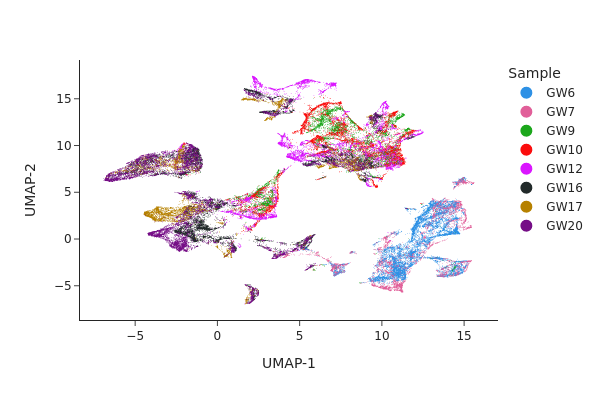

In [27]:
snap.pl.umap(data, color="Sample", interactive=False)

## Batch correction

In [65]:
%%time
snap.pp.mnc_correct(data, 
                    batch="Sample")

CPU times: user 55min 46s, sys: 53min 56s, total: 1h 49min 42s
Wall time: 2min 3s


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



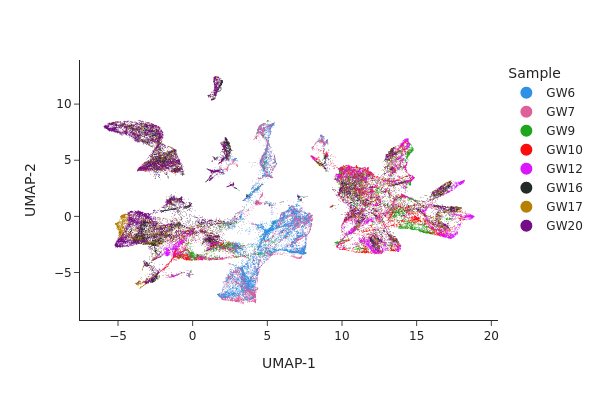

In [66]:
snap.tl.umap(data, use_rep="X_spectral_mnn")
snap.pl.umap(data, color="Sample", interactive=False)

## Clustering

In [67]:
snap.pp.knn(data, use_rep="X_spectral_mnn")

In [68]:
snap.tl.leiden(data, resolution = 1.8)

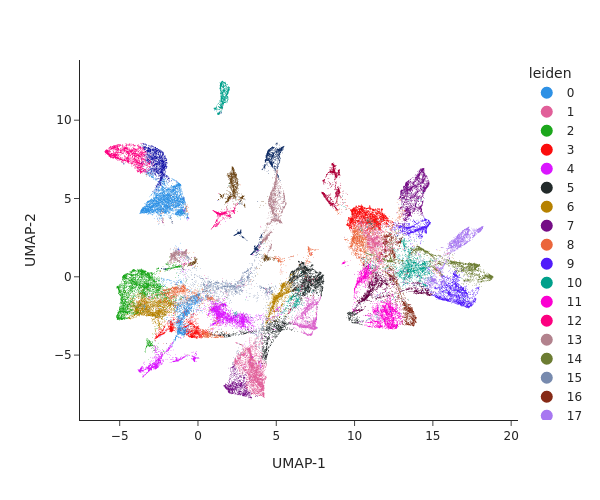

In [69]:
snap.pl.umap(data, color="leiden", interactive=False, height=500)

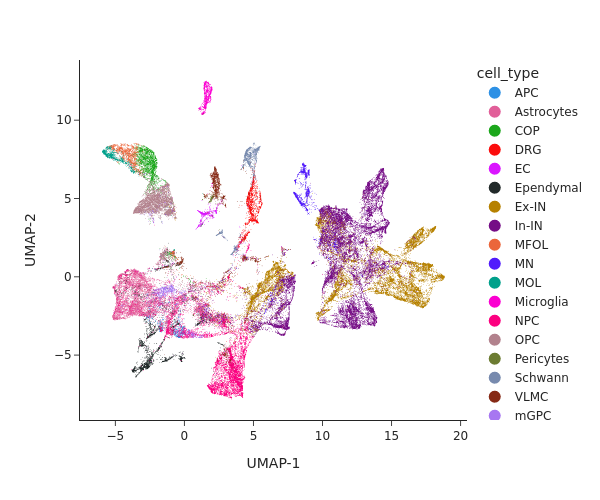

In [70]:
snap.pl.umap(data, color="cell_type", interactive=False, height=500)

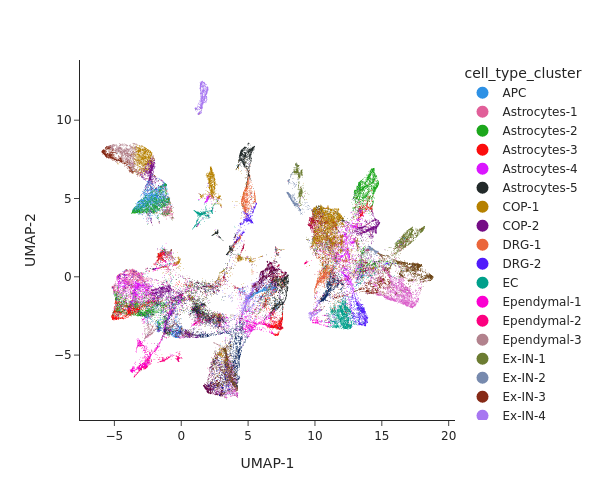

In [71]:
snap.pl.umap(data, color="cell_type_cluster", interactive=False, height=500)

In [72]:
data

AnnDataSet object with n_obs x n_vars = 82514 x 606219 backed at './hsc_filtered_anndataset/_dataset.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'cell_type', 'cell_type_dual', 'cell_type_cluster', 'cluster_res_2.8', 'cell_type_order', 'bc'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'spectral_eigenvalue', 'reference_sequences'
    obsm: 'fragment_paired', 'X_spectral_harmony', 'X_spectral_mnn', 'X_spectral', 'X_umap'
    obsp: 'distances'

In [73]:
hsc_umaped = data.to_adata()

In [74]:
hsc_umaped.write('hsc_umaped.h5ad')

... storing 'Sample' as categorical
... storing 'cell_type' as categorical
... storing 'cell_type_dual' as categorical
... storing 'cell_type_cluster' as categorical
... storing 'cell_type_order' as categorical


In [75]:
data.close()

In [76]:
data

Closed AnnDataSet object

## Create the cell by gene activity matrix

In [77]:
hsc_umaped = snap.read("hsc_umaped.h5ad", backed=None)
hsc_umaped

AnnData object with n_obs × n_vars = 82514 × 606219
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'cell_type', 'cell_type_dual', 'cell_type_cluster', 'cluster_res_2.8', 'cell_type_order', 'bc'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_spectral_mnn', 'X_umap', 'fragment_paired'
    obsp: 'distances'

In [78]:
gene_matrix = snap.pp.make_gene_matrix(hsc_umaped, snap.genome.hg38, upstream=1000, downstream=1000, include_gene_body=True) 
gene_matrix

AnnData object with n_obs × n_vars = 82514 × 60606
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'cell_type', 'cell_type_dual', 'cell_type_cluster', 'cluster_res_2.8', 'cell_type_order', 'bc'

In [79]:
gene_matrix.var_names

Index(['DDX11L1', 'WASH7P', 'MIR6859-1', 'MIR1302-2HG', 'MIR1302-2', 'FAM138A',
       'OR4G4P', 'OR4G11P', 'OR4F5', 'ENSG00000238009',
       ...
       'MT-ND4', 'MT-TH', 'MT-TS2', 'MT-TL2', 'MT-ND5', 'MT-ND6', 'MT-TE',
       'MT-CYB', 'MT-TT', 'MT-TP'],
      dtype='object', length=60606)

In [80]:
gene_matrix.write('gene_matrix.h5ad')